# Scientific Programming in Python - Control Flow & File IO

### Problem 1. FizzBuzz

>**(a)** Write a program that prints out the numbers between one and 100 except that:
* for multiples of three it prints the word Fizz instead of that number;
* for multiples of five it prints the word Buzz instead of that number; and
* for multiples of both three and five it prints the word FizzBuzz instead of that number.

>For example, the first 15 lines of output from your program should be identical to the following:

In [ ]:
for num in range(1, 101):
    if num % 3 == 0 and num % 5 == 0:
        print("Fizz", end=" ")
    elif num % 3 == 0:
        print("Fizz", end=" ")
    elif num % 5 == 0:
        print("Buzz", end=" ")
    else:
        print(num, end=" ")

1 2 Fizz 4 Buzz Fizz 7 8 Fizz Buzz 11 Fizz 13 14 Fizz 16 17 Fizz 19 Buzz Fizz 22 23 Fizz Buzz 26 Fizz 28 29 Fizz 31 32 Fizz 34 Buzz Fizz 37 38 Fizz Buzz 41 Fizz 43 44 Fizz 46 47 Fizz 49 Buzz Fizz 52 53 Fizz Buzz 56 Fizz 58 59 Fizz 61 62 Fizz 64 Buzz Fizz 67 68 Fizz Buzz 71 Fizz 73 74 Fizz 76 77 Fizz 79 Buzz Fizz 82 83 Fizz Buzz 86 Fizz 88 89 Fizz 91 92 Fizz 94 Buzz Fizz 97 98 Fizz Buzz 

>**Hint:** If you are having trouble, start by writing code that will print all the numbers one to 100, one per line. Then, modify that code so that it prints the word Fizz instead of multiples of three. Next, modify your code to prints the word Buzz instead of multiples of five. Finally, modify it so that it prints the correct output.

>**Hint:** To test if a variable <code>n</code> is a multiple of three, you can use this code:

>><code>(n % 3) == 0</code>

> The <code>%</code> symbol here is called the [modulo operator](https://en.wikipedia.org/wiki/Modulo_operation) and the code <code>n % 3</code> is pronounced "n modulo three". So if <code>n</code> is zero modulo three, it gives 0 remainder on division by three and that means it’s a multiple of 3. You can use the code like this:

>><code>if (n % 3) == 0:
    do_stuff </code>

>Here, <code>do_stuff</code> will be executed if and only if <code>n</code> is a multiple of 3.

### Problem 2. Library with File I/O

In this problem, you are given a list of student names and library fees in a file and your task is to write some Python code to process it. Make sure you download [library_data.txt](http://ucl-cs-grad.github.io/scipython/notebooks/day2/library_data.txt) from the website and put it in the same folder as your iPython notebook. The file looks something like this:

In [ ]:
import urllib.request

# 파일 다운로드 URL
url = "http://ucl-cs-grad.github.io/scipython/notebooks/day2/library_data.txt"

# 현재 폴더에 library_data.txt로 저장
urllib.request.urlretrieve(url, "library_data.txt")
print("다운로드 완료!")

다운로드 완료!


Each line in the file is a single student record. Each student record has the following format:
><code>StudentNumber FirstName LastName AmountOwed</code>

>**(a)** Write a function that uses a for-loop to iterate over each line in the file and store it in a list. The resulting list should look something like this:

In [ ]:
def load_library_data(file_path="library_data.txt"):
    data_list = []

    # 텍스트 파일 읽기 모드로 열기
    with open(file_path, "r") as f:
        for line in f:
            # 줄바꿈 제거하고 공백 기준으로 자르기
            info = line.strip().split()

            # 빈 줄이 아닌 경우에만 리스트에 추가
            if info:
                # 연체료(마지막 값)는 float 타입으로 변환해서 저장
                student_id = info[0]
                first_name = info[1]
                last_name = info[2]
                amount = float(info[3])

                data_list.append([student_id, first_name, last_name, amount])

    return data_list

# 함수 실행 결과 받아오기
result = load_library_data("library_data.txt")
print(result)

[['123456', 'John', 'Doe', 1.49], ['312314', 'Jane', 'Miller', 0.0], ['531337', 'Ted', 'Johnson', 8.12], ['273263', 'Johnny', 'Depp', 0.0], ['102931', 'Fred', 'Asteir', 1.2], ['391273', 'Sarah', 'Connor', 10.39]]


>**(b)** Write a function to create two lists:
>1. A list that contains only the first column (the student number)
>2. A list that contains only the remaining information (the student name and the amount of money owed to the library)

>**Hint:** You could use the string method <code>split</code> to split a string into a list of smaller strings. Read the help for this function if needed.

In [ ]:
def split_student_info(records):
    ids = []
    details = []

    for row in records:
        ids.append(row[0])      # 학번만 저장
        details.append(row[1:]) # 나머지 정보 저장

    return ids, details

# 테스트
student_ids, student_info = split_student_info(result)
print(student_ids[:3])
print(student_info[:3])

['123456', '312314', '531337']
[['John', 'Doe', 1.49], ['Jane', 'Miller', 0.0], ['Ted', 'Johnson', 8.12]]


>**(c)** Write a function that splits the second list futher into two lists:
>1. A list that contains the name
>2. A list that contains the amount owed (as a float)

In [ ]:
def split_details(details):
    names = []
    amounts = []

    for item in details:
        # 이름과 성 합치기
        full_name = item[0] + " " + item[1]
        names.append(full_name)

        # 연체료 float으로 변환해서 저장
        amounts.append(float(item[2]))

    return names, amounts

# (b)번 결과 사용해서 테스트
student_names, student_amounts = split_details(student_info)

print(student_names[:3])
print(student_amounts[:3])

['John Doe', 'Jane Miller', 'Ted Johnson']
[1.49, 0.0, 8.12]


>**(d)** Write a function that determines the name and student number of the person that owes the largest amount of money.

In [ ]:
def find_max_debtor(ids, names, amounts):
    # 가장 높은 연체료의 인덱스 찾기
    max_idx = amounts.index(max(amounts))

    # 해당 인덱스의 학번과 이름 가져오기
    max_id = ids[max_idx]
    max_name = names[max_idx]

    return max_name, max_id

# 앞서 구해둔 리스트들로 테스트
top_name, top_id = find_max_debtor(student_ids, student_names, student_amounts)

print("최대 연체자 이름:", top_name)
print("최대 연체자 학번:", top_id)

최대 연체자 이름: Sarah Connor
최대 연체자 학번: 391273


>**(e)** Write a function that determines the names and student numbers of all people that owe money (i.e. where the amount is not 0.00).

In [ ]:
def get_debtors(ids, names, amounts):
    debtor_ids = []
    debtor_names = []

    for i in range(len(amounts)):
        # 연체료가 0보다 큰 학생만 추출
        if amounts[i] > 0:
            debtor_ids.append(ids[i])
            debtor_names.append(names[i])

    return debtor_names, debtor_ids

# 테스트
debt_names, debt_ids = get_debtors(student_ids, student_names, student_amounts)

# 결과 출력
print("연체자 이름:", debt_names[:5])
print("연체자 학번:", debt_ids[:5])

연체자 이름: ['John Doe', 'Ted Johnson', 'Fred Asteir', 'Sarah Connor']
연체자 학번: ['123456', '531337', '102931', '391273']


>**(f)** We will now write our results to a new file. Write some code that:
> 1. lets the user enter a file name;
> 2. creates this file; and
> 3. writes to the file the list of people that owe money (e.g. one student per line, with how much they owe as well).

In [ ]:
# 파일 이름 입력받기
filename = input("파일 이름을 입력하세요: ")

# 연체자 정보(학번, 이름, 연체금)를 파일에 쓰기
with open(filename, "w") as f:
    for i in range(len(student_amounts)):
        if student_amounts[i] > 0:
            # 한 줄씩 문자열로 만들어서 쓰기
            line = str(student_ids[i]) + " " + str(student_names[i]) + " " + str(student_amounts[i]) + "\n"
            f.write(line)

파일 이름을 입력하세요: owing_students.txt


### Problem 3. FizzBuzz (applied science version)

Imagine that you are doing a psychology experiment in which your colleague records the response time of participants presented with some task. There are two task conditions: condition A and condition B. There are n participants, and they each do the task with condition A and then with condition B. The instrument used to record the response times stores the information in a long text file called response_time.txt (which you can get [here](http://ucl-cs-grad.github.io/scipython/notebooks/day2/response_time.txt)). The first line of the file is the response time of the first participant doing the task with condition A, the second line is the response time of the first participant with condition B, the third line is the response time of the second participant doing the task with condition A, and so on.

>**(a)** Download [response_time.txt](http://ucl-cs-grad.github.io/scipython/notebooks/day2/response_time.txt) and then write a program which prints the mean response time of all participants for task A followed by the mean response time for all participants for task B. The output of your program should be the following:

>**Hint:** The modulo operator should come in handy again. Any appropriately indented code following <code> if (n % 2) == 0: </code> will only be executed if <code>n</code> is even.

In [ ]:
import urllib.request

url = "http://ucl-cs-grad.github.io/scipython/notebooks/day2/response_time.txt"
urllib.request.urlretrieve(url, "response_time.txt")

condition_A = []
condition_B = []

with open("response_time.txt", "r") as f:
    lines = f.readlines()

    for i in range(len(lines)):
        val = float(lines[i].strip())

        # 짝수 인덱스
        if i % 2 == 0:
            condition_A.append(val)
        # 홀수 인덱스
        else:
            condition_B.append(val)

mean_a = sum(condition_A) / len(condition_A)
mean_b = sum(condition_B) / len(condition_B)

print("Mean response time for task A:", mean_a)
print("Mean response time for task B:", mean_b)

Mean response time for task A: 4.98704579794635
Mean response time for task B: 3.1046195690006404


>**(b)** Extend your script so that it displays a box plot of the response times of the participants for the two conditions.

>**Hint:**  If you create two lists, called <code>condition_A</code> and <code>condition_B</code>, containing the response times for conditions A and B respectively, then the <code>boxplot</code> function from matplotlib will generate the actual boxplot:
>><code>boxplot( [condition_A, condition_B] )</code>.

/tmp/ipykernel_3212/1111355575.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([condition_A, condition_B], labels=['Condition A', 'Condition B'])


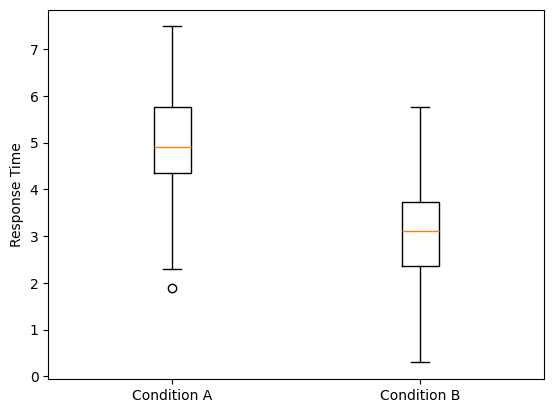

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot([condition_A, condition_B], labels=['Condition A', 'Condition B'])
plt.ylabel('Response Time')

plt.show()

### Problem 4. Who’s the winner?

The London elections are around the corner and you have been tasked with writing the code that determines the winner given all the ballots. The winner is determined as follows:

* From the list of candidates (which we will for simplicity number $0,1,2,...$ ), every voter gets to select his first and his second choice. The data you are given can thus be represented as a list of lists:

><code>[ [1st_choice_voter_1, 2nd_choice_voter_1], [1st_choice_voter_2, 2nd_choice_voter_2], ...]</code>

* If any of the candidates gets more than 50% of the first votes, he is declared the winner.


* If no candidate achieves this absolute majority, the two candidates with the most first votes enter into a second round, all others are eliminated.  


* In the second round, all ballots with first votes for candidates that did not enter the second round are re-examined, and any second choice votes for the top two candidates are added to their scores.  


* The candidate with the highest number of combined first and second choice votes is the winner.  

>**(a)** Download the file [votes.pickle](ucl-cs-grad.github.io/scipython/notebooks/day2/votes.pickle) from the course website. Then, use the following code to read the list of votes from the file:

In [ ]:
import os
import pickle
import urllib.request

filename = "votes.pickle"
if not os.path.exists(filename):
    url = "http://ucl-cs-grad.github.io/scipython/notebooks/day2/votes.pickle"
    urllib.request.urlretrieve(url, filename)

# 파일 읽기
with open(filename, "rb") as f:
    votes = pickle.load(f)

>**(b)** Fill in the code required to count the first votes and to determine the possible first-round winner. There are 6 candidates in the given data set. You should find that in this data set no candidate wins in the first round.

In [ ]:
num_candidates = 6

# create a list to store the number of votes per candidate
first_votes = [0] * num_candidates

# go through the list of votes and add up the first votes per candidate
for vote in votes:
    first_choice = vote[0]
    first_votes[first_choice] += 1

print(first_votes)


# in the first round, if any candidate has > 50% of the votes, he wins
total_votes = len(votes)
winner = None

for candidate in range(num_candidates):
    if first_votes[candidate] > total_votes / 2:
        winner = candidate

if winner is not None:
    print("1차 라운드 승리자:", winner)
else:
    print("1차 라운드에서 과반수 넘은 사람 없음.")

[10010, 26969, 23130, 4959, 14848, 20084]
1차 라운드에서 과반수 넘은 사람 없음.


>**(c)** Implement the second round process described above. If you do this correctly, you should find that candidate 2 wins with 45619 votes. There are some hints in the skeleton below to get you started

In [ ]:
# For the elimination round, we need to find the two candidates with the most first votes.
# The code below does just that: It returns a tuple of the indices of the
# top two candidates. Don't worry if you don't understand how this works yet --
# we will see a much simpler and more elegant way to achieve the same later in the course.
elimination_candidates  = list( zip ( *sorted( zip( first_votes, range( len(first_votes) ) ) )[-2:] ))[1]

# make a copy so we can add votes
second_votes = first_votes[:]

# add second votes to first votes for remaining candidates

for vote in votes:
    first_choice = vote[0]
    second_choice = vote[1]

    # 1순위 후보가 탈락했고, 2순위 후보가 결선 진출자 2명 중 한 명인 경우
    if first_choice not in elimination_candidates and second_choice in elimination_candidates:
        second_votes[second_choice] += 1

print(second_votes)

# find and display the winner
# you can either try to adapt the code used to find the top two candidates above,
# or simply use another for loop

winning_candidate = None
max_votes = -1

for candidate in elimination_candidates:
    if second_votes[candidate] > max_votes:
        max_votes = second_votes[candidate]
        winning_candidate = candidate

print(f"{winning_candidate}번 후보가 {max_votes}표로 승리했습니다!")

[10010, 44374, 45619, 4959, 14848, 20084]
2번 후보가 45619표로 승리했습니다!


### Problem 5. Text processing for Alice in Wonderland

The following code will create a file called alice.txt that contains the text of Alice in Wonderland. The code below will create the file in iPython’s current directory. This is the same as going to the website http://www.guttenberg.org/, finding the .txt file for Alice in Wonderland, and clicking *File* and then *Save as* and entering ‘alice.txt’ into the save dialog of your browser. The advantage of knowing how to do this in python is that you can then write a script to automatically download the data that you need for an experiment, which will save you time when there are a lot of files.

In [ ]:
import urllib.request

# Local URL on UCL webserver
URL = "http://ucl-cs-grad.github.io/scipython/notebooks/day2/alice.txt"

local_filename, headers = urllib.request.urlretrieve(URL)
f = open(local_filename)
open("alice.txt", "w").write( f.read() )

163810

>**(a)** Open up the file ‘alice.txt’ in a text editor of your choice (e.g. Notepad on Windows or TextEdit on Mac). There might be some text at the beginning or the end that isn’t part of Alice in Wonderland. Delete it and then save the file again.

In [ ]:
with open("alice.txt", "r", encoding="utf-8") as f:
    text = f.read()

# 소설의 시작 위치 (CHAPTER I)
start_marker = "CHAPTER I"
# 소설의 끝 위치 (THE END)
end_marker = "THE END"

start_pos = text.find(start_marker)
end_pos = text.find(end_marker) + len(end_marker)

clean_text = text[start_pos:end_pos]

with open("alice.txt", "w", encoding="utf-8") as f:
    f.write(clean_text)

In [ ]:
with open("alice.txt", "r", encoding="utf-8") as f:
    for i in range(10):
        print(f.readline().strip())

CHAPTER I. Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into the
book her sister was reading, but it had no pictures or conversations in
it, 'and what is the use of a book,' thought Alice 'without pictures or
conversations?'

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure


In [ ]:
with open("alice.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()
    for line in lines[-20:]:
        print(line.strip())

Wonderland, though she knew she had but to open them again, and all
would change to dull reality--the grass would be only rustling in the
wind, and the pool rippling to the waving of the reeds--the rattling
teacups would change to tinkling sheep-bells, and the Queen's shrill
cries to the voice of the shepherd boy--and the sneeze of the baby, the
shriek of the Gryphon, and all the other queer noises, would change (she
knew) to the confused clamour of the busy farm-yard--while the lowing
of the cattle in the distance would take the place of the Mock Turtle's
heavy sobs.

Lastly, she pictured to herself how this same little sister of hers
would, in the after-time, be herself a grown woman; and how she would
keep, through all her riper years, the simple and loving heart of her
childhood: and how she would gather about her other little children, and
make THEIR eyes bright and eager with many a strange tale, perhaps even
with the dream of Wonderland of long ago: and how she would feel with
a

>**(b)** The following code will count the number of words in Alice in Wonderland. Modify the code so that it prints out the number of times the word Alice appears.

In [ ]:
f = open("alice.txt", "r", encoding="utf-8")
num_alice = 0

for line in f.readlines():
    for word in line.strip().split():
        # 문장부호를 제거하고 대소문자 구분 없이 'alice'인지 확인
        cleaned_word = word.strip(".,?!\"'():;").lower()
        if cleaned_word == "alice":
            num_alice += 1

f.close()

print(num_alice)

385


We will revisit this exercise later when dictionaries have been introduced to analyse the frequency of all words!

### Problem 6. Cryptograms

The code below ‘encrypts’ some text by rotating the alphabet by a given amount:

In [ ]:
amount = int( input('What amount do you want to rotate by? ') )

print('Enter text to be rotated.')
print('Enter "EOF" on a line on its own when you are done.')

A_value = ord('A')
Z_value = ord('Z')

while True:
    input_line = input()

    if input_line == 'EOF':
        break

    output_line = ''

    for c in input_line:
        if c.isalpha():
            c = c.upper()
            value = ord(c)
            value = value + amount

            if value > Z_value:
                value = A_value + (value - Z_value) - 1
            elif value < A_value:
                value = Z_value - (A_value - value) + 1

            c = chr(value)

        output_line += c

    print(output_line)

What amount do you want to rotate by? 3
Enter text to be rotated.
Enter "EOF" on a line on its own when you are done.
hello
KHOOR
eof
HRI
EOF


>**(a)** If you encrypt some text by rotating some amount, what amount do you need to rotate by to decrypt it?

>> 암호화할 때 이동한 수(N) 만큼의 음수값(-N)으로 돌리거나 26-N만큼 회전시키면 된다.

>**(b)** Encrypt some text and email it to the person next to you. Tell them what amount you rotated by so they can decrypt it.

>**(c)** Figure out what <code>ord</code> and <code>chr</code> do
- ord(): 문자를 아스키 숫자 코드로 변환한다.

- chr(): 아스키 숫자 코드를 문자로 변환한다.

>**(d)** Do you understand the bit where it wraps around by checking if it’s moved past ‘A’ or ‘Z’?
>> 'Z'를 넘어가면 'A'부터 다시 시작하고, 'A'보다 작아지면 'Z'부터 역순으로 돌아가게 만든다.

>**(e)** What does this part of the code do:

>><code>while True:
    input_line = input()
    if input_line == "EOF":
        break</code>

>>> 사용자 입력을 계속 받다가 EOF가 입력되면 while 문을 끝낸다.

>**(f)** You should notice that our program converts lower case to upper case letters as a side effect as it rotates. Change it so that it doesn’t convert lower case to upper case (instead preserving the case of the letters) but still rotates them.

In [ ]:
amount = int(input("What amount do you want to rotate by? "))

print("Enter text to be rotated.")
print('Enter "EOF" on a line on its own when you are done.')

# 대문자와 소문자의 아스키 코드 범위 설정
A_upper, Z_upper = ord("A"), ord("Z")
A_lower, Z_lower = ord("a"), ord("z")

while True:
    input_line = input()

    if input_line == "EOF":
        break

    output_line = ""

    for c in input_line:
        if c.isalpha():
            # 대문자인 경우
            if c.isupper():
                value = ord(c) + amount
                if value > Z_upper:
                    value = A_upper + (value - Z_upper) - 1
                elif value < A_upper:
                    value = Z_upper - (A_upper - value) + 1
                c = chr(value)

            # 소문자인 경우
            elif c.islower():
                value = ord(c) + amount
                if value > Z_lower:
                    value = A_lower + (value - Z_lower) - 1
                elif value < A_lower:
                    value = Z_lower - (A_lower - value) + 1
                c = chr(value)

        output_line += c

    print(output_line)

What amount do you want to rotate by? 3
Enter text to be rotated.
Enter "EOF" on a line on its own when you are done.
hello
khoor
Hello
Khoor
EOF
